--- 1. ДОСЛІДНИЦЬКИЙ АНАЛІЗ ДАНИХ (EDA) ---
--- Основні цифри (Середне, Медіана, Квартилі) ---
count    8760.000000
mean       80.441192
std        25.686709
min        37.819000
25%        58.404750
50%        78.603500
75%        98.753250
max       140.090000
Name: value, dtype: float64

--- Перевірка на пропуски (має бути 0) ---
meter_id      0
ts            0
value         0
temp          0
irrad         0
hour          0
day_name      0
month         0
is_weekend    0
dtype: int64


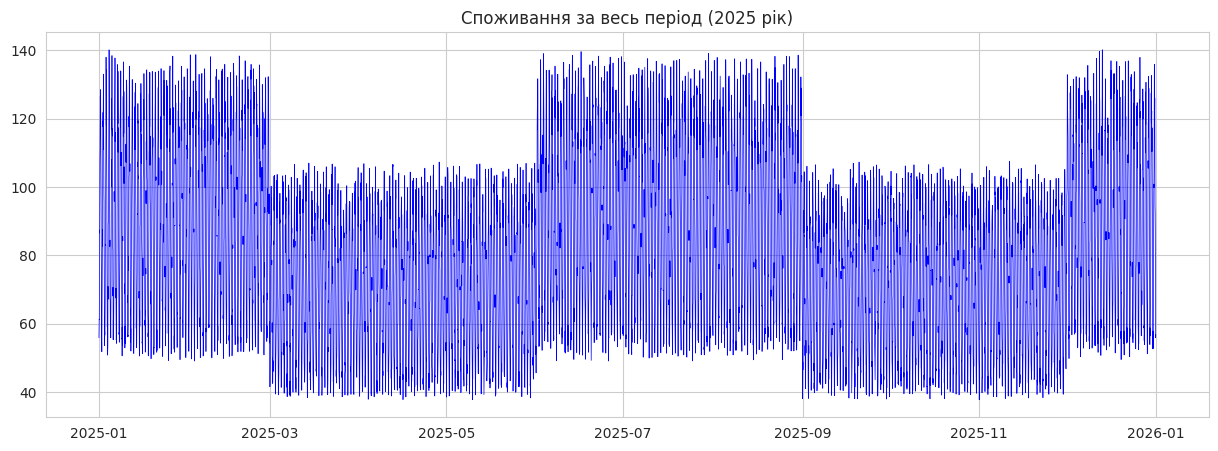

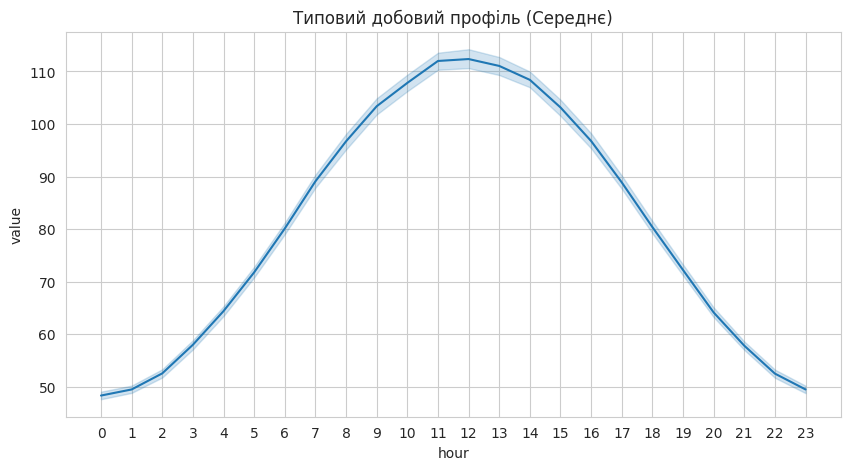

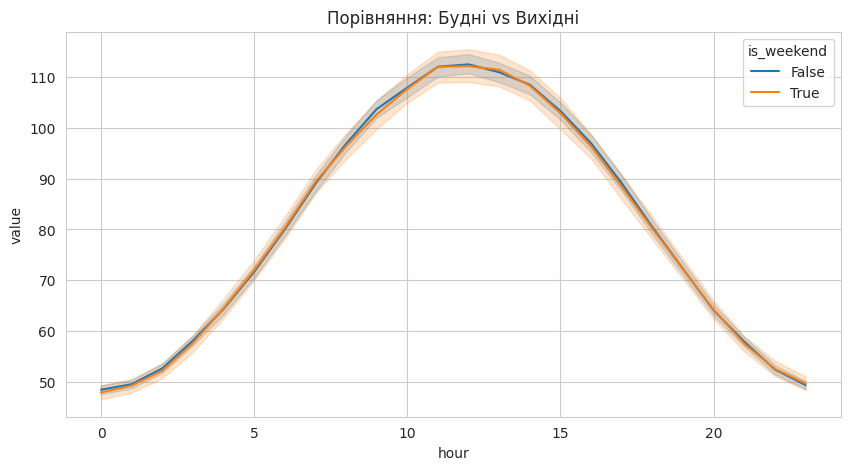

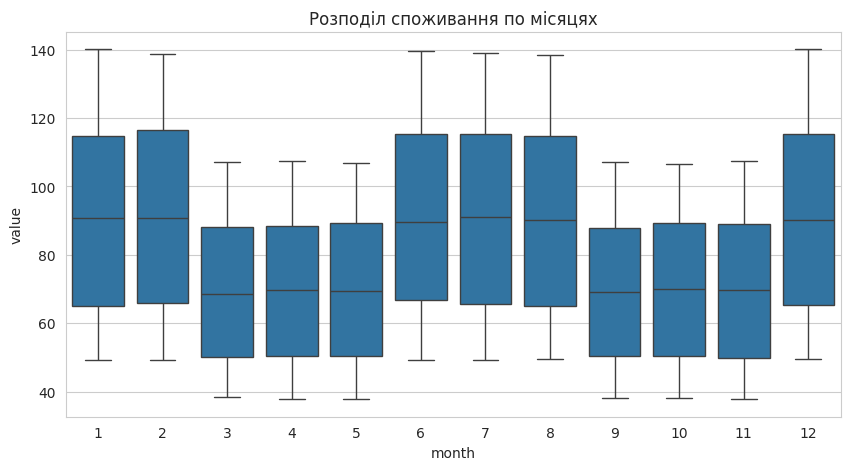

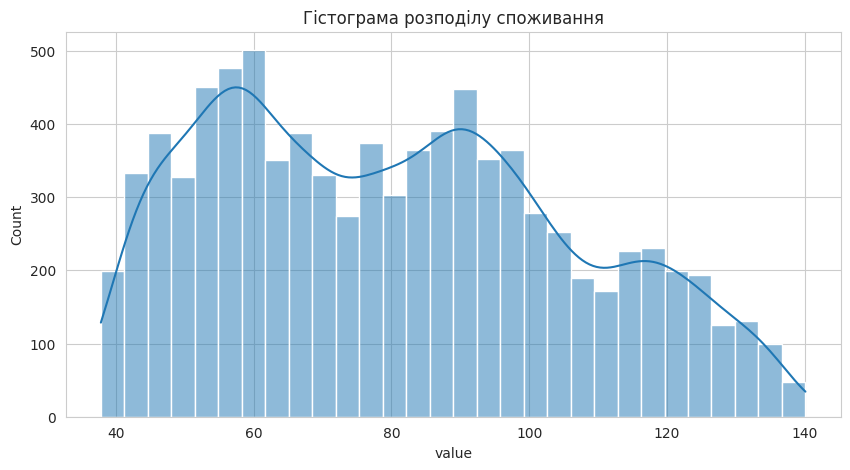

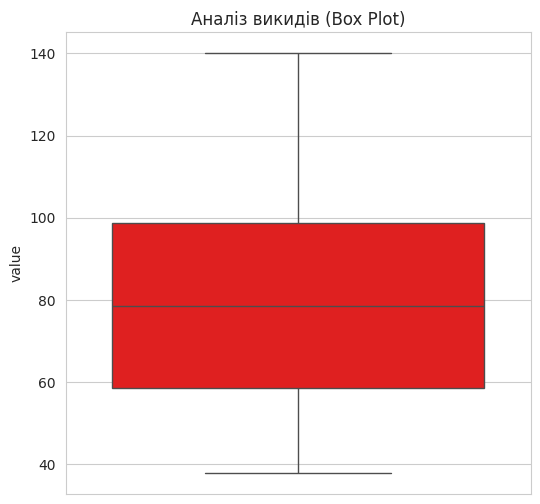

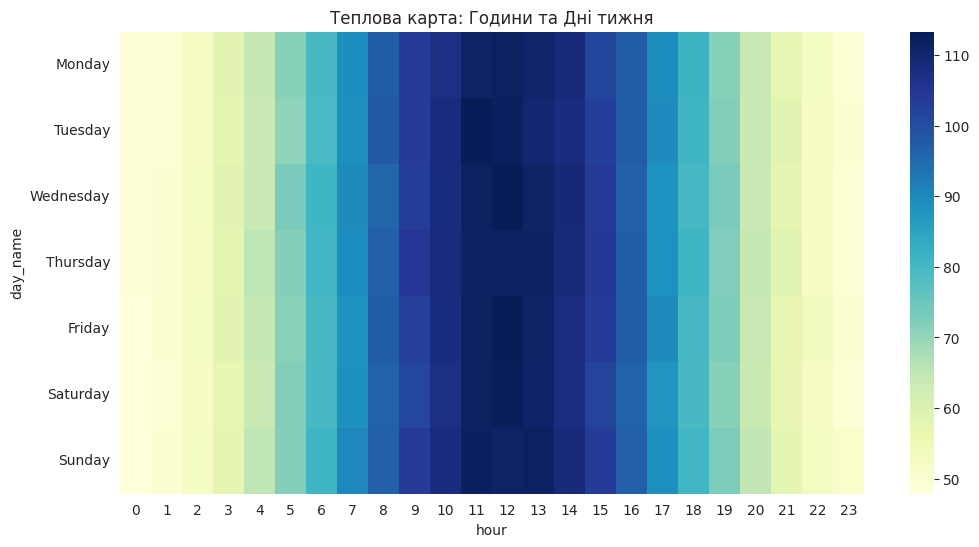

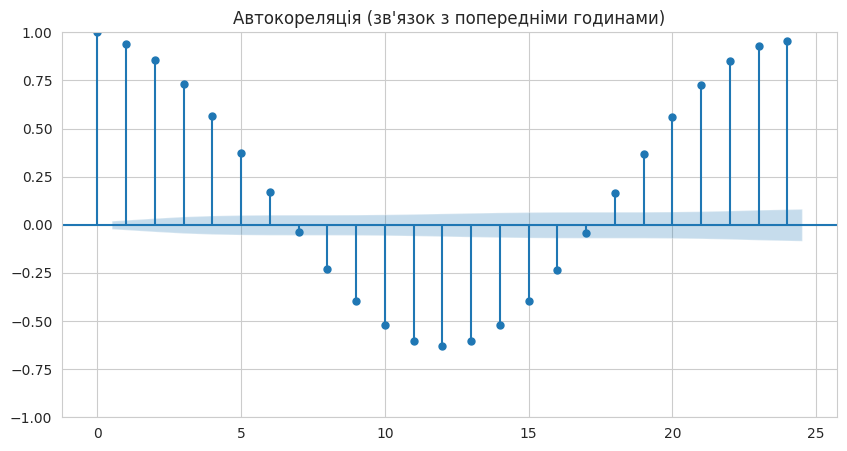

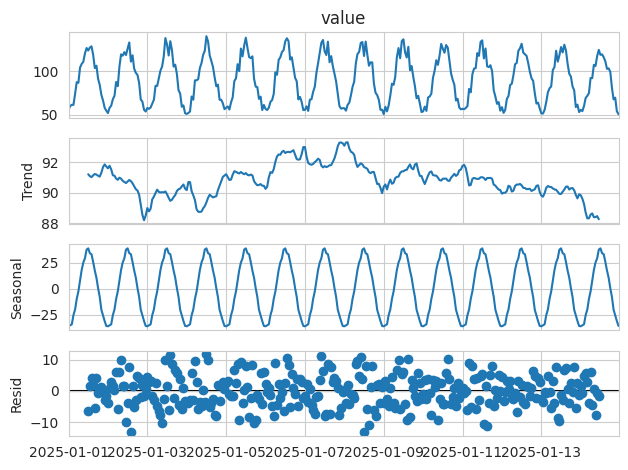


--- 2. ФАКТОРНИЙ АНАЛІЗ ---
--- Матриця кореляції (вплив на 'value') ---
value    1.000000
irrad    0.791544
CDD      0.025589
temp     0.005442
HDD     -0.001100
Name: value, dtype: float64


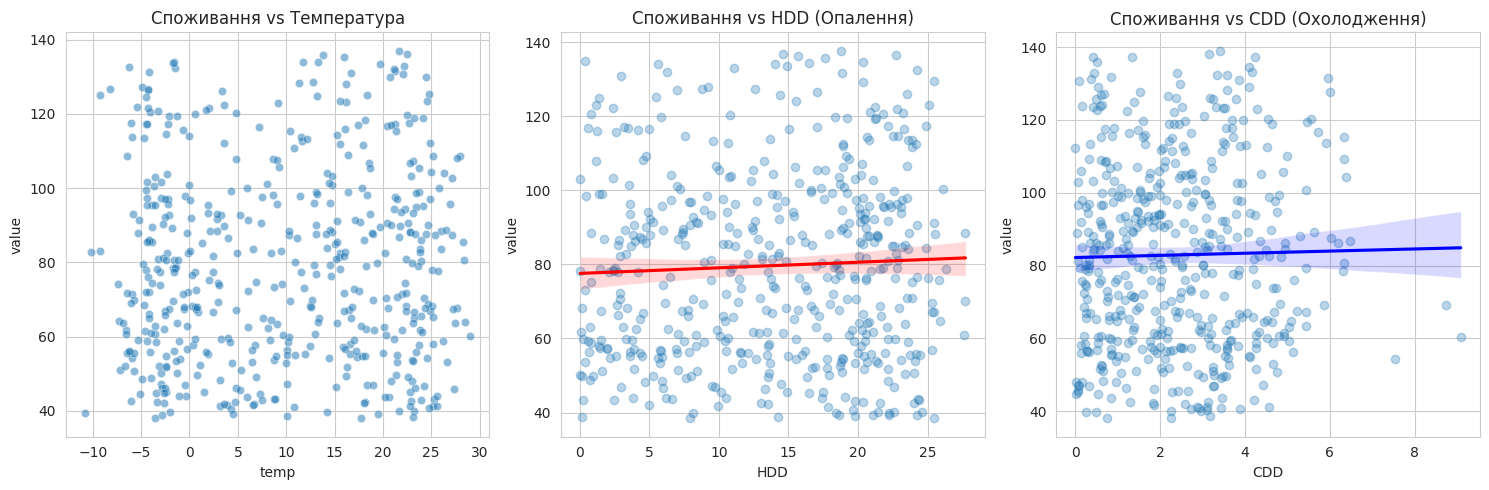


--- 3. ПОБУДОВА МОДЕЛЕЙ ---
Linear Regression R2: 0.9556
Random Forest R2: 0.9593


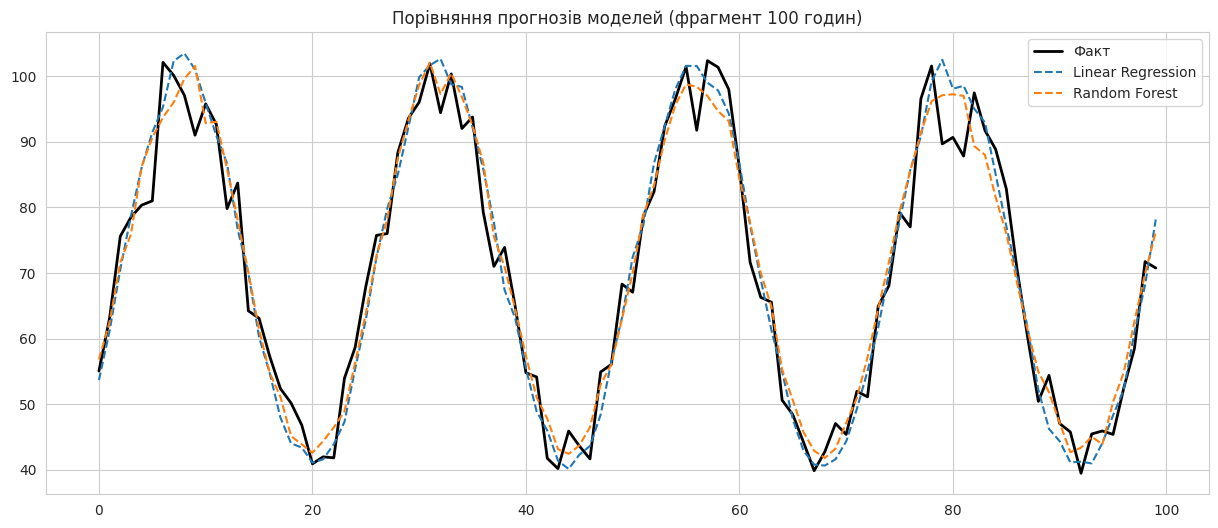


--- 4. ОЦІНКА ТА ПРОГНОЗУВАННЯ ---
--- Порівняльна таблиця моделей ---
              Модель        R2      RMSE       MAE  MAPE (%)
0  Linear Regression  0.955595  5.261602  4.231632  5.466570
1      Random Forest  0.959265  5.039471  3.979800  5.073714


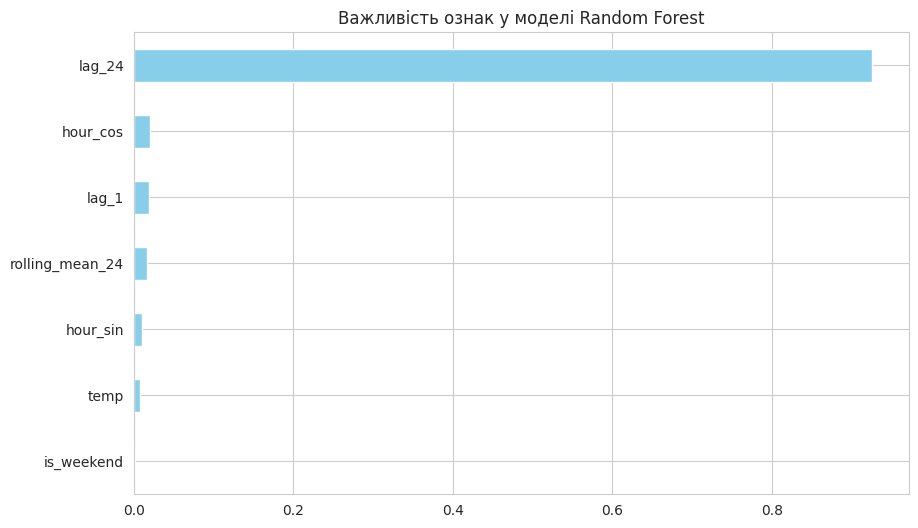


--- Прогноз на наступний місяць ---
Очікуване споживання: 56739.85 кВт·год
Очікувана вартість: 368809.01 грн


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

df_readings = pd.read_csv('/kaggle/input/datasets/vovan4oman/readings/readings.csv', parse_dates=['ts'])
df_weather = pd.read_csv('/kaggle/input/datasets/vovan4oman/weather/weather.csv', parse_dates=['ts'])

df = df_readings[df_readings['meter_id'] == 1].merge(df_weather, on='ts')

df['hour'] = df['ts'].dt.hour
df['day_name'] = df['ts'].dt.day_name()
df['month'] = df['ts'].dt.month
df['is_weekend'] = df['ts'].dt.dayofweek.isin([5, 6])

print("--- 1. ДОСЛІДНИЦЬКИЙ АНАЛІЗ ДАНИХ (EDA) ---")
print("--- Основні цифри (Середне, Медіана, Квартилі) ---")
print(df['value'].describe())

print("\n--- Перевірка на пропуски (має бути 0) ---")
print(df.isnull().sum())

sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))
plt.plot(df['ts'], df['value'], color='blue', linewidth=0.5)
plt.title('Споживання за весь період (2025 рік)')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='value')
plt.title('Типовий добовий профіль (Середнє)')
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='value', hue='is_weekend')
plt.title('Порівняння: Будні vs Вихідні')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='month', y='value')
plt.title('Розподіл споживання по місяцях')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['value'], bins=30, kde=True)
plt.title('Гістограма розподілу споживання')
plt.show()

plt.figure(figsize=(6, 6))
sns.boxplot(y=df['value'], color='red')
plt.title('Аналіз викидів (Box Plot)')
plt.show()

pivot = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(days)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Теплова карта: Години та Дні тижня')
plt.show()

plt.figure(figsize=(10, 5))
plot_acf(df['value'], lags=24, ax=plt.gca())
plt.title('Автокореляція (зв\'язок з попередніми годинами)')
plt.show()

df_small = df.iloc[:24*14].set_index('ts') 
decomp = seasonal_decompose(df_small['value'], model='additive', period=24)
decomp.plot()
plt.show()

print("\n--- 2. ФАКТОРНИЙ АНАЛІЗ ---")
df['HDD'] = df['temp'].apply(lambda x: max(0, 18 - x))
df['CDD'] = df['temp'].apply(lambda x: max(0, x - 22))

corr_matrix = df[['value', 'temp', 'HDD', 'CDD', 'irrad']].corr()
print("--- Матриця кореляції (вплив на 'value') ---")
print(corr_matrix['value'].sort_values(ascending=False))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df.sample(500), x='temp', y='value', alpha=0.5)
plt.title('Споживання vs Температура')

plt.subplot(1, 3, 2)
sns.regplot(data=df[df['HDD'] > 0].sample(500), x='HDD', y='value', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Споживання vs HDD (Опалення)')

plt.subplot(1, 3, 3)
sns.regplot(data=df[df['CDD'] > 0].sample(500), x='CDD', y='value', scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.title('Споживання vs CDD (Охолодження)')
plt.tight_layout()
plt.show()

print("\n--- 3. ПОБУДОВА МОДЕЛЕЙ ---")
df['lag_1'] = df['value'].shift(1)
df['lag_24'] = df['value'].shift(24)
df['rolling_mean_24'] = df['value'].rolling(window=24).mean()
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23)

df_ml = df.dropna()
features = ['hour_sin', 'hour_cos', 'temp', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24']
X = df_ml[features]
y = df_ml['value']

train_size = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Факт', color='black', linewidth=2)
plt.plot(y_pred_lr[:100], label='Linear Regression', linestyle='--')
plt.plot(y_pred_rf[:100], label='Random Forest', linestyle='--')
plt.title('Порівняння прогнозів моделей (фрагмент 100 годин)')
plt.legend()
plt.show()

print("\n--- 4. ОЦІНКА ТА ПРОГНОЗУВАННЯ ---")
def get_metrics(y_true, y_pred, name):
    return {
        'Модель': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

metrics_df = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, 'Linear Regression'),
    get_metrics(y_test, y_pred_rf, 'Random Forest')
])

print("--- Порівняльна таблиця моделей ---")
print(metrics_df)

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Важливість ознак у моделі Random Forest')
plt.show()

avg_daily_cons = y_pred_rf.mean() * 24
monthly_cons = avg_daily_cons * 30
expected_cost = monthly_cons * 6.5 

print(f"\n--- Прогноз на наступний місяць ---")
print(f"Очікуване споживання: {monthly_cons:.2f} кВт·год")
print(f"Очікувана вартість: {expected_cost:.2f} грн")